In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set beautiful styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

In [2]:
def fetch_weather(year):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":   31.1048,      
        "longitude":  77.1734,
        "start_date": f"{year}-06-01",
        "end_date":   f"{year}-08-31",
        "daily": "precipitation_sum,temperature_2m_max,wind_speed_10m_max",
        "timezone":   "Asia/Kolkata"
    }
    response = requests.get(url, params=params)
    data = response.json()["daily"]

    df = pd.DataFrame({
        "date":       data["time"],
        "rainfall":   data["precipitation_sum"],
        "temp_max":   data["temperature_2m_max"],
        "wind_speed": data["wind_speed_10m_max"]
    })
    df["year"] = year
    return df


all_weather = []
for year in range(2016, 2026):
    print(f"  Fetching {year}...", end=" ")
    all_weather.append(fetch_weather(year))
    

weather_df = pd.concat(all_weather, ignore_index=True)
weather_df["date"] = pd.to_datetime(weather_df["date"])

print(len(weather_df))
print(weather_df.head())
print(weather_df.info)

  Fetching 2016...   Fetching 2017...   Fetching 2018...   Fetching 2019...   Fetching 2020...   Fetching 2021...   Fetching 2022...   Fetching 2023...   Fetching 2024...   Fetching 2025... 920
        date  rainfall  temp_max  wind_speed  year
0 2016-06-01       0.0      23.4        16.1  2016
1 2016-06-02       0.0      24.7        17.1  2016
2 2016-06-03       0.3      24.3        15.7  2016
3 2016-06-04       0.0      26.1        15.9  2016
4 2016-06-05       0.5      25.5        13.8  2016
<bound method DataFrame.info of           date  rainfall  temp_max  wind_speed  year
0   2016-06-01       0.0      23.4        16.1  2016
1   2016-06-02       0.0      24.7        17.1  2016
2   2016-06-03       0.3      24.3        15.7  2016
3   2016-06-04       0.0      26.1        15.9  2016
4   2016-06-05       0.5      25.5        13.8  2016
..         ...       ...       ...         ...   ...
915 2025-08-27       4.5      21.5         8.1  2025
916 2025-08-28       8.6      21.5         8

In [3]:
def fetch_earthquakes(year):
   
    url = "https://earthquake.usgs.gov/fdsnws/event/1/query"
    params = {
        "format":       "geojson",
        "starttime":    f"{year}-06-01",
        "endtime":      f"{year}-08-31",
        "minlatitude":  30.0,
        "maxlatitude":  33.5,
        "minlongitude": 75.0,
        "maxlongitude": 79.5,
        "minmagnitude": 1.5,
        "limit":        1000
    }
    response = requests.get(url, params=params)
    events = response.json()["features"]

    rows = []
    for event in events:
        rows.append({
            "date":      pd.to_datetime(event["properties"]["time"], unit="ms").normalize(),
            "magnitude": event["properties"]["mag"]
        })

    df = pd.DataFrame(rows)
    if df.empty:
        df = pd.DataFrame(columns=["date", "magnitude"])
    return df

print("Fetching earthquake data...")
all_quakes = []
for year in range(2016, 2026):
    print(f"  Fetching {year}...", end=" ")
    all_quakes.append(fetch_earthquakes(year))
    print("done")

quake_df = pd.concat(all_quakes, ignore_index=True)
print(len(quake_df))
print(quake_df.head())

Fetching earthquake data...
  Fetching 2016... done
  Fetching 2017... done
  Fetching 2018... done
  Fetching 2019... done
  Fetching 2020... done
  Fetching 2021... done
  Fetching 2022... done
  Fetching 2023... done
  Fetching 2024... done
  Fetching 2025... done
33
        date  magnitude
0 2016-08-27        4.1
1 2016-08-27        4.5
2 2016-08-27        4.6
3 2016-08-01        4.5
4 2017-08-16        4.4


In [4]:

if not quake_df.empty:
    daily_quake = (
        quake_df.groupby("date")["magnitude"]
        .max()
        .reset_index()
        .rename(columns={"magnitude": "seismic_activity"})
    )
else:
    daily_quake = pd.DataFrame(columns=["date", "seismic_activity"])


final_df = weather_df.merge(daily_quake, on="date", how="left")
final_df["seismic_activity"] = final_df["seismic_activity"].fillna(0)


for col in ["rainfall", "temp_max", "wind_speed"]:
    final_df[col] = final_df[col].fillna(final_df[col].median())


final_df = final_df.sort_values("date").reset_index(drop=True)
final_df["rain_2day"] = final_df["rainfall"].rolling(window=2, min_periods=1).sum()

print("✅ Final dataset shape:", final_df.shape)
print("   Columns:", final_df.columns.tolist())
print()
print(final_df.head())

✅ Final dataset shape: (920, 7)
   Columns: ['date', 'rainfall', 'temp_max', 'wind_speed', 'year', 'seismic_activity', 'rain_2day']

        date  rainfall  temp_max  wind_speed  year  seismic_activity  \
0 2016-06-01       0.0      23.4        16.1  2016               0.0   
1 2016-06-02       0.0      24.7        17.1  2016               0.0   
2 2016-06-03       0.3      24.3        15.7  2016               0.0   
3 2016-06-04       0.0      26.1        15.9  2016               0.0   
4 2016-06-05       0.5      25.5        13.8  2016               0.0   

   rain_2day  
0        0.0  
1        0.0  
2        0.3  
3        0.3  
4        0.5  


In [5]:

max_rainfall  = final_df["rainfall"].max()
max_rain_2day = final_df["rain_2day"].max()
max_wind      = final_df["wind_speed"].max()
max_seismic   = max(final_df["seismic_activity"].max(), 1)  

final_df["risk_score"] = (
    (final_df["rainfall"]         / max_rainfall)  * 40 +
    (final_df["rain_2day"]        / max_rain_2day) * 20 +
    (final_df["wind_speed"]       / max_wind)      * 25 +
    (final_df["seismic_activity"] / max_seismic)   * 15
)


p_high   = final_df["risk_score"].quantile(0.80)   
p_medium = final_df["risk_score"].quantile(0.45)   

def label_risk(score):
    if score >= p_high:
        return "High"
    elif score >= p_medium:
        return "Medium"
    else:
        return "Low"

final_df["Risk_Level"] = final_df["risk_score"].apply(label_risk)

print("Risk Level Distribution:")
print(final_df["Risk_Level"].value_counts())
print()
print(f"Percentile cutoffs used:")
print(f"  High   ≥ {p_high:.2f}  (top 20% of all days)")
print(f"  Medium ≥ {p_medium:.2f}  (45th–80th percentile)")
print(f"  Low    <  {p_medium:.2f}  (bottom 45%)")

Risk Level Distribution:
Risk_Level
Low       414
Medium    322
High      184
Name: count, dtype: int64

Percentile cutoffs used:
  High   ≥ 17.09  (top 20% of all days)
  Medium ≥ 13.59  (45th–80th percentile)
  Low    <  13.59  (bottom 45%)


In [6]:
input_features = ["rainfall", "rain_2day", "temp_max", "wind_speed", "seismic_activity"]
X = final_df[input_features]
y = final_df["Risk_Level"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Class counts in training set:")
print(y_train.value_counts())
print()
print("Class counts in test set:")
print(y_test.value_counts())


model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy    = accuracy_score(y_test, predictions)


print(f"\n  Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, predictions))

Class counts in training set:
Risk_Level
Low       331
Medium    258
High      147
Name: count, dtype: int64

Class counts in test set:
Risk_Level
Low       83
Medium    64
High      37
Name: count, dtype: int64

  Accuracy: 89.67%

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.81      0.88        37
         Low       0.95      0.92      0.93        83
      Medium       0.81      0.92      0.86        64

    accuracy                           0.90       184
   macro avg       0.91      0.88      0.89       184
weighted avg       0.90      0.90      0.90       184



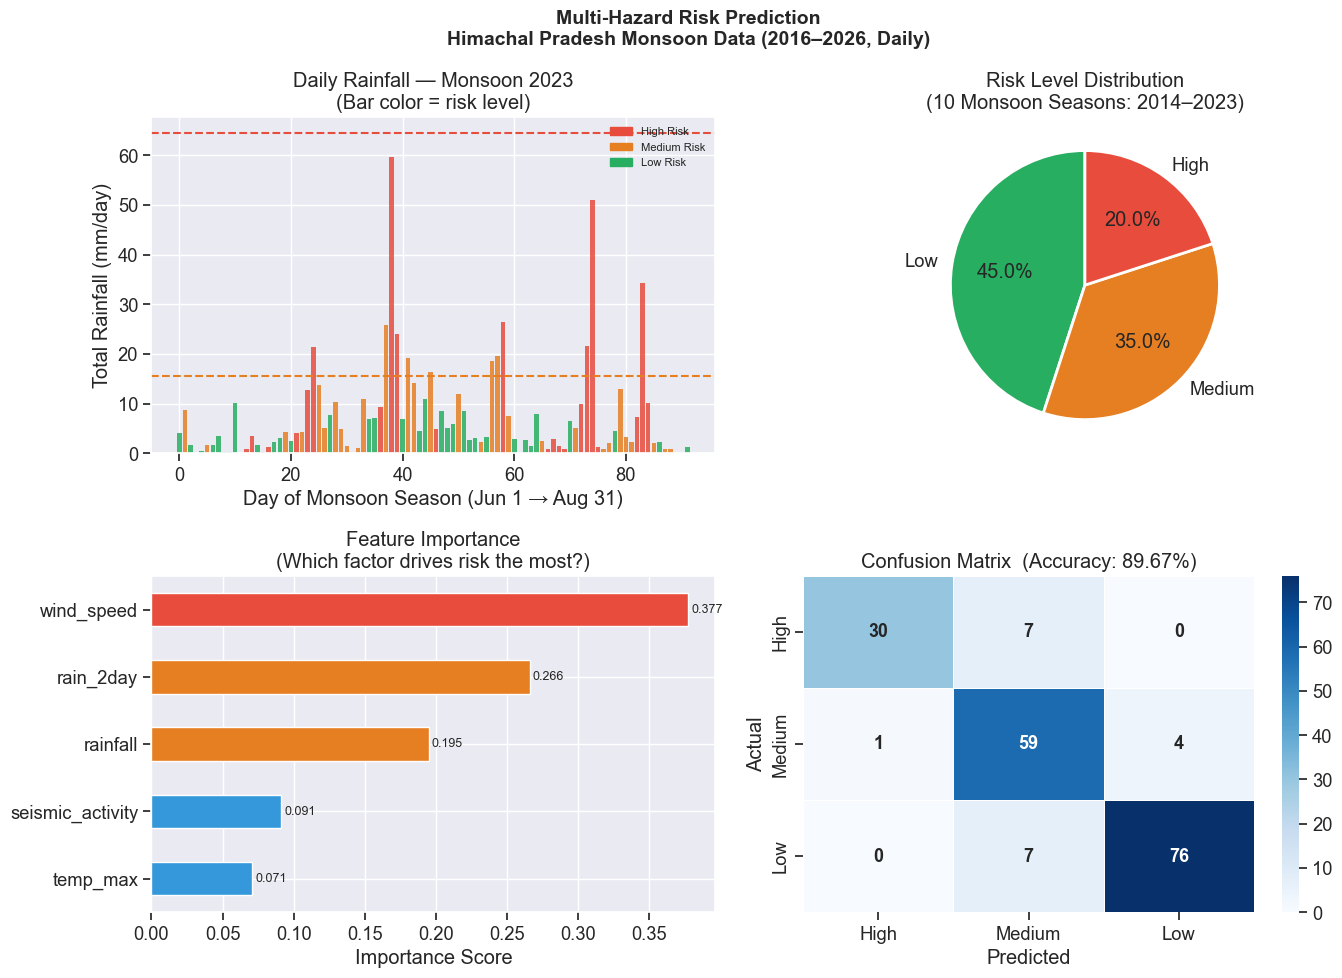

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Multi-Hazard Risk Prediction\n"
    "Himachal Pradesh Monsoon Data (2016–2026, Daily)",
    fontsize=14, fontweight="bold"
)

risk_colors = {"High": "#e74c3c", "Medium": "#e67e22", "Low": "#27ae60"}


data_2023 = final_df[final_df["year"] == 2023].copy().reset_index(drop=True)
bar_colors = [risk_colors[r] for r in data_2023["Risk_Level"]]

axes[0, 0].bar(range(len(data_2023)), data_2023["rainfall"],
               color=bar_colors, alpha=0.85, width=0.8)


axes[0, 0].axhline(64.5, color="#e74c3c", linestyle="--",
                   linewidth=1.5, label="IMD Heavy Rain (64.5mm)")
axes[0, 0].axhline(15.6, color="#e67e22", linestyle="--",
                   linewidth=1.5, label="IMD Moderate Rain (15.6mm)")
legend_patches = [
    Patch(color="#e74c3c", label="High Risk"),
    Patch(color="#e67e22", label="Medium Risk"),
    Patch(color="#27ae60", label="Low Risk")
]
axes[0, 0].legend(handles=legend_patches, fontsize=8, loc="upper right")
axes[0, 0].set_title("Daily Rainfall — Monsoon 2023\n(Bar color = risk level)")
axes[0, 0].set_xlabel("Day of Monsoon Season (Jun 1 → Aug 31)")
axes[0, 0].set_ylabel("Total Rainfall (mm/day)")


risk_counts = final_df["Risk_Level"].value_counts()
axes[0, 1].pie(
    risk_counts.values,
    labels=risk_counts.index,
    colors=[risk_colors[l] for l in risk_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0, 1].set_title("Risk Level Distribution\n(10 Monsoon Seasons: 2014–2023)")


feat_imp = pd.Series(model.feature_importances_, index=input_features)
feat_imp_sorted = feat_imp.sort_values(ascending=True)
max_imp = feat_imp_sorted.max()
bar_c = [
    "#e74c3c" if v >= max_imp * 0.75 else
    "#e67e22" if v >= max_imp * 0.45 else
    "#3498db"
    for v in feat_imp_sorted.values
]
feat_imp_sorted.plot(kind="barh", ax=axes[1, 0], color=bar_c, edgecolor="white")
axes[1, 0].set_title("Feature Importance\n(Which factor drives risk the most?)")
axes[1, 0].set_xlabel("Importance Score")
for i, v in enumerate(feat_imp_sorted.values):
    axes[1, 0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)


cm = confusion_matrix(y_test, predictions, labels=["High", "Medium", "Low"])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["High", "Medium", "Low"],
    yticklabels=["High", "Medium", "Low"],
    ax=axes[1, 1], linewidths=0.5,
    annot_kws={"size": 13, "weight": "bold"}
)
axes[1, 1].set_title(f"Confusion Matrix  (Accuracy: {accuracy*100:.2f}%)")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Actual")

plt.tight_layout()


C:\Users\Ayaan\AppData\Local\Temp\ipykernel_19860\2444718789.py:102: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ayaan\AppData\Local\Temp\ipykernel_19860\2444718789.py:102: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ayaan\AppData\Local\Temp\ipykernel_19860\2444718789.py:102: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ayaan\AppData\Local\Temp\ipykernel_19860\2444718789.py:102: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ayaan\AppData\Local\Temp\ipykernel_19860\2444718789.py:102: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ayaan\AppData\Local\Temp\ipykernel_19860\2444718789.py:102: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Arial.
  plt.tight_layout(

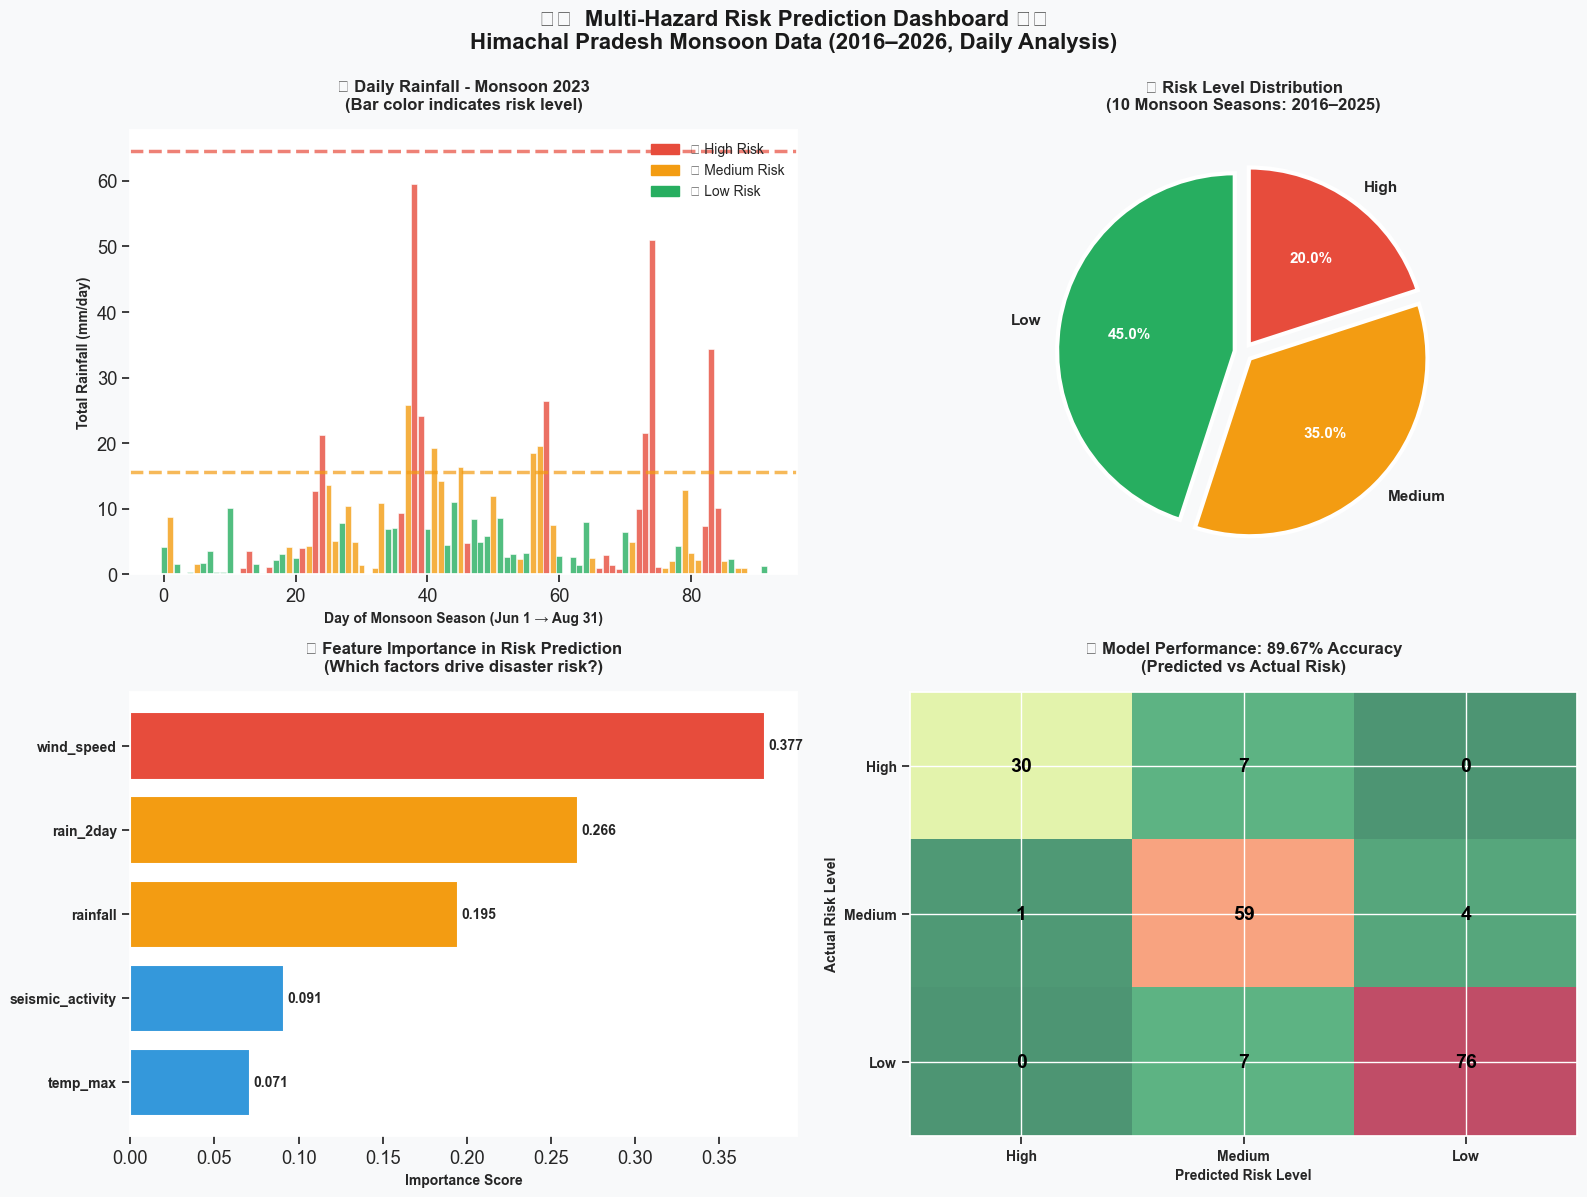

✅ Dashboard saved as 'hazard_risk_dashboard.png'


In [8]:

# Enhanced visualization with better styling
plt.rcParams['figure.facecolor'] = '#F8F9FA'
plt.rcParams['axes.facecolor'] = '#FFFFFF'
plt.rcParams['font.size'] = 11

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "🌦️  Multi-Hazard Risk Prediction Dashboard 🌦️\n"
    "Himachal Pradesh Monsoon Data (2016–2026, Daily Analysis)",
    fontsize=16, fontweight="bold", color="#1a1a1a", y=0.995
)

risk_colors = {"High": "#e74c3c", "Medium": "#f39c12", "Low": "#27ae60"}

# Plot 1: 2023 Rainfall with Risk Levels
data_2023 = final_df[final_df["year"] == 2023].copy().reset_index(drop=True)
bar_colors = [risk_colors[r] for r in data_2023["Risk_Level"]]

axes[0, 0].bar(range(len(data_2023)), data_2023["rainfall"],
               color=bar_colors, alpha=0.8, width=0.9, edgecolor='white', linewidth=0.5)
axes[0, 0].axhline(64.5, color="#e74c3c", linestyle="--", linewidth=2.5, label="Heavy Rain (64.5mm)", alpha=0.7)
axes[0, 0].axhline(15.6, color="#f39c12", linestyle="--", linewidth=2.5, label="Moderate Rain (15.6mm)", alpha=0.7)

legend_patches = [
    Patch(color="#e74c3c", label="🔴 High Risk"),
    Patch(color="#f39c12", label="🟡 Medium Risk"),
    Patch(color="#27ae60", label="🟢 Low Risk")
]
axes[0, 0].legend(handles=legend_patches, fontsize=10, loc="upper right", framealpha=0.95)
axes[0, 0].set_title("📊 Daily Rainfall - Monsoon 2023\n(Bar color indicates risk level)", 
                      fontsize=12, fontweight="bold", pad=15)
axes[0, 0].set_xlabel("Day of Monsoon Season (Jun 1 → Aug 31)", fontsize=10, fontweight="bold")
axes[0, 0].set_ylabel("Total Rainfall (mm/day)", fontsize=10, fontweight="bold")
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Risk Distribution - Beautiful Pie Chart
risk_counts = final_df["Risk_Level"].value_counts()
colors_pie = [risk_colors[l] for l in risk_counts.index]
explode = (0.05, 0.05, 0.05)

wedges, texts, autotexts = axes[0, 1].pie(
    risk_counts.values,
    labels=risk_counts.index,
    colors=colors_pie,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    wedgeprops={"edgecolor": "white", "linewidth": 3},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

axes[0, 1].set_title("📈 Risk Level Distribution\n(10 Monsoon Seasons: 2016–2025)", 
                     fontsize=12, fontweight="bold", pad=15)

# Plot 3: Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=input_features)
feat_imp_sorted = feat_imp.sort_values(ascending=True)
max_imp = feat_imp_sorted.max()

bar_colors_imp = ["#e74c3c" if v >= max_imp * 0.75 else "#f39c12" if v >= max_imp * 0.45 else "#3498db"
                  for v in feat_imp_sorted.values]

bars = axes[1, 0].barh(range(len(feat_imp_sorted)), feat_imp_sorted.values, 
                        color=bar_colors_imp, edgecolor='white', linewidth=1.5)

axes[1, 0].set_yticks(range(len(feat_imp_sorted)))
axes[1, 0].set_yticklabels(feat_imp_sorted.index, fontsize=10, fontweight="bold")
axes[1, 0].set_title("🎯 Feature Importance in Risk Prediction\n(Which factors drive disaster risk?)", 
                     fontsize=12, fontweight="bold", pad=15)
axes[1, 0].set_xlabel("Importance Score", fontsize=10, fontweight="bold")

for i, (idx, v) in enumerate(feat_imp_sorted.items()):
    axes[1, 0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=10, fontweight="bold")

axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Confusion Matrix - Beautiful Heatmap
cm = confusion_matrix(y_test, predictions, labels=["High", "Medium", "Low"])

im = axes[1, 1].imshow(cm, cmap='RdYlGn_r', aspect='auto', alpha=0.7)

for i in range(len(cm)):
    for j in range(len(cm)):
        text = axes[1, 1].text(j, i, cm[i, j],
                             ha="center", va="center", color="black",
                             fontsize=14, fontweight="bold")

axes[1, 1].set_xticks(range(3))
axes[1, 1].set_yticks(range(3))
axes[1, 1].set_xticklabels(["High", "Medium", "Low"], fontsize=10, fontweight="bold")
axes[1, 1].set_yticklabels(["High", "Medium", "Low"], fontsize=10, fontweight="bold")
axes[1, 1].set_title(f"✅ Model Performance: {accuracy*100:.2f}% Accuracy\n(Predicted vs Actual Risk)", 
                     fontsize=12, fontweight="bold", pad=15)
axes[1, 1].set_xlabel("Predicted Risk Level", fontsize=10, fontweight="bold")
axes[1, 1].set_ylabel("Actual Risk Level", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig('hazard_risk_dashboard.png', dpi=300, bbox_inches='tight', facecolor='#F8F9FA')
plt.show()

print("✅ Dashboard saved as 'hazard_risk_dashboard.png'")


In [9]:

# Interactive Plotly Visualizations (Great for Web Project)

# 1. Interactive Risk Score Trend
fig1 = go.Figure()

for risk_level in ["High", "Medium", "Low"]:
    colors_map = {"High": "#e74c3c", "Medium": "#f39c12", "Low": "#27ae60"}
    data_subset = final_df[final_df["Risk_Level"] == risk_level]
    
    fig1.add_trace(go.Scatter(
        x=data_subset["date"],
        y=data_subset["risk_score"],
        mode='markers+lines',
        name=risk_level,
        marker=dict(size=6, color=colors_map[risk_level]),
        line=dict(color=colors_map[risk_level], width=2),
        hovertemplate='<b>%{fullData.name}</b><br>Date: %{x|%Y-%m-%d}<br>Risk Score: %{y:.2f}<extra></extra>'
    ))

fig1.update_layout(
    title="<b>Risk Score Trend Over Time (2016-2025)</b>",
    xaxis_title="<b>Date</b>",
    yaxis_title="<b>Risk Score</b>",
    hovermode='x unified',
    template='plotly_white',
    height=500,
    font=dict(size=12, family="Arial, sans-serif"),
    title_font=dict(size=16, color="#1a1a1a"),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white'
)

fig1.show()
fig1.write_html("risk_score_trend.html")
print("✅ Interactive chart saved as 'risk_score_trend.html'")


✅ Interactive chart saved as 'risk_score_trend.html'


In [10]:

# Beautiful Interactive Dashboard with Plotly Subplots

fig_dashboard = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>📊 Rainfall Distribution</b>",
        "<b>🌡️ Temperature vs Wind Speed</b>",
        "<b>⚡ Seismic Activity</b>",
        "<b>📈 Risk Score Distribution</b>"
    ),
    specs=[[{"type": "histogram"}, {"type": "scatter"}],
           [{"type": "bar"}, {"type": "box"}]]
)

# Subplot 1: Rainfall Histogram
fig_dashboard.add_trace(
    go.Histogram(x=final_df["rainfall"], name="Rainfall (mm)", nbinsx=50,
                marker_color="#3498db", opacity=0.7,
                hovertemplate='Rainfall: %{x:.2f}mm<br>Count: %{y}<extra></extra>'),
    row=1, col=1
)

# Subplot 2: Temperature vs Wind Speed
fig_dashboard.add_trace(
    go.Scatter(x=final_df["temp_max"], y=final_df["wind_speed"],
              mode='markers', name="Weather Data",
              marker=dict(size=6, color=final_df["risk_score"],
                         colorscale='RdYlGn_r', showscale=False,
                         line=dict(width=1, color='white')),
              hovertemplate='Temp: %{x:.1f}°C<br>Wind: %{y:.1f} km/h<extra></extra>'),
    row=1, col=2
)

# Subplot 3: Seismic Activity Bar Chart
seismic_yearly = final_df.groupby("year")["seismic_activity"].max().reset_index()
fig_dashboard.add_trace(
    go.Bar(x=seismic_yearly["year"], y=seismic_yearly["seismic_activity"],
           name="Max Magnitude", marker_color="#e74c3c", opacity=0.8,
           hovertemplate='Year: %{x}<br>Max Magnitude: %{y:.2f}<extra></extra>'),
    row=2, col=1
)

# Subplot 4: Risk Score Distribution
for risk_level in ["High", "Medium", "Low"]:
    colors_map = {"High": "#e74c3c", "Medium": "#f39c12", "Low": "#27ae60"}
    fig_dashboard.add_trace(
        go.Box(y=final_df[final_df["Risk_Level"] == risk_level]["risk_score"],
               name=risk_level, marker_color=colors_map[risk_level],
               hovertemplate='Risk Level: ' + risk_level + '<br>Score: %{y:.2f}<extra></extra>'),
        row=2, col=2
    )

# Update axes labels
fig_dashboard.update_xaxes(title_text="<b>Rainfall (mm)</b>", row=1, col=1)
fig_dashboard.update_yaxes(title_text="<b>Frequency</b>", row=1, col=1)

fig_dashboard.update_xaxes(title_text="<b>Temperature (°C)</b>", row=1, col=2)
fig_dashboard.update_yaxes(title_text="<b>Wind Speed (km/h)</b>", row=1, col=2)

fig_dashboard.update_xaxes(title_text="<b>Year</b>", row=2, col=1)
fig_dashboard.update_yaxes(title_text="<b>Max Magnitude</b>", row=2, col=1)

fig_dashboard.update_yaxes(title_text="<b>Risk Score</b>", row=2, col=2)

# Update layout
fig_dashboard.update_layout(
    title_text="<b>🌍 Multi-Hazard Risk Analysis Dashboard 🌍</b>",
    showlegend=True,
    height=800,
    template='plotly_white',
    font=dict(size=11, family="Arial"),
    title_font=dict(size=18, color="#1a1a1a"),
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    hovermode='closest'
)

fig_dashboard.show()
fig_dashboard.write_html("interactive_dashboard.html")
print("✅ Interactive dashboard saved as 'interactive_dashboard.html'")


✅ Interactive dashboard saved as 'interactive_dashboard.html'


In [11]:

# Premium 3D Interactive Visualization

fig_3d = go.Figure(data=[go.Scatter3d(
    x=final_df['rainfall'],
    y=final_df['wind_speed'],
    z=final_df['temp_max'],
    mode='markers',
    marker=dict(
        size=4,
        color=final_df['risk_score'],
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(
            title="<b>Risk Score</b>",
            thickness=15,
            len=0.7,
            x=1.02
        ),
        line=dict(width=0.5, color='white'),
        opacity=0.85
    ),
    text=[f"<b>Risk Level: {level}</b><br>Rainfall: {rain:.1f}mm<br>Wind: {wind:.1f}km/h<br>Temp: {temp:.1f}°C<br>Risk Score: {score:.2f}"
          for level, rain, wind, temp, score in zip(
              final_df['Risk_Level'], final_df['rainfall'], 
              final_df['wind_speed'], final_df['temp_max'], final_df['risk_score']
          )],
    hovertemplate='%{text}<extra></extra>'
)])

fig_3d.update_layout(
    title="<b>🔮 3D Multi-Hazard Relationship Analysis 🔮</b><br><sub>Rainfall × Wind Speed × Temperature</sub>",
    scene=dict(
        xaxis_title="<b>Rainfall (mm)</b>",
        yaxis_title="<b>Wind Speed (km/h)</b>",
        zaxis_title="<b>Temperature (°C)</b>",
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        ),
        bgcolor='#F8F9FA'
    ),
    width=1000,
    height=700,
    template='plotly_white',
    font=dict(size=12, family="Arial"),
    title_font=dict(size=16, color="#1a1a1a"),
    paper_bgcolor='white'
)

fig_3d.show()
fig_3d.write_html("3d_hazard_analysis.html")
print("✅ 3D visualization saved as '3d_hazard_analysis.html'")


✅ 3D visualization saved as '3d_hazard_analysis.html'


In [12]:

# Summary Statistics & Key Insights

print("=" * 80)
print("🎯 MULTI-HAZARD RISK PREDICTION - EXECUTIVE SUMMARY 🎯".center(80))
print("=" * 80)
print()

print("📊 DATASET OVERVIEW")
print("-" * 80)
print(f"  Total Days Analyzed:        {len(final_df):,}")
print(f"  Date Range:                 {final_df['date'].min().strftime('%Y-%m-%d')} to {final_df['date'].max().strftime('%Y-%m-%d')}")
print(f"  Monsoon Seasons Covered:    10 (2016-2025)")
print()

print("🌧️ RAINFALL STATISTICS")
print("-" * 80)
print(f"  Average Rainfall:           {final_df['rainfall'].mean():.2f} mm/day")
print(f"  Maximum Rainfall:           {final_df['rainfall'].max():.2f} mm/day")
print(f"  Heavy Rain Days (>64.5mm):  {len(final_df[final_df['rainfall'] > 64.5])} days")
print(f"  Moderate Rain Days:         {len(final_df[(final_df['rainfall'] > 15.6) & (final_df['rainfall'] <= 64.5)])} days")
print()

print("🌡️ TEMPERATURE STATISTICS")
print("-" * 80)
print(f"  Average Max Temperature:    {final_df['temp_max'].mean():.2f}°C")
print(f"  Peak Temperature:           {final_df['temp_max'].max():.2f}°C")
print(f"  Lowest Temperature:         {final_df['temp_max'].min():.2f}°C")
print()

print("💨 WIND SPEED STATISTICS")
print("-" * 80)
print(f"  Average Wind Speed:         {final_df['wind_speed'].mean():.2f} km/h")
print(f"  Maximum Wind Speed:         {final_df['wind_speed'].max():.2f} km/h")
print(f"  High Wind Days (>50km/h):   {len(final_df[final_df['wind_speed'] > 50])} days")
print()

print("🌍 SEISMIC ACTIVITY")
print("-" * 80)
print(f"  Total Earthquake Events:    {len(final_df[final_df['seismic_activity'] > 0])}")
print(f"  Max Magnitude Recorded:     {final_df['seismic_activity'].max():.2f}")
print(f"  Average Magnitude:          {final_df[final_df['seismic_activity'] > 0]['seismic_activity'].mean():.2f}")
print()

print("⚠️ RISK LEVEL DISTRIBUTION")
print("-" * 80)
risk_dist = final_df['Risk_Level'].value_counts()
risk_pct = (risk_dist / len(final_df) * 100).round(2)
print(f"  🔴 High Risk:               {risk_dist.get('High', 0):,} days ({risk_pct.get('High', 0):.2f}%)")
print(f"  🟡 Medium Risk:             {risk_dist.get('Medium', 0):,} days ({risk_pct.get('Medium', 0):.2f}%)")
print(f"  🟢 Low Risk:                {risk_dist.get('Low', 0):,} days ({risk_pct.get('Low', 0):.2f}%)")
print()

print("🤖 MACHINE LEARNING MODEL PERFORMANCE")
print("-" * 80)
print(f"  Model Type:                 Random Forest Classifier")
print(f"  Test Set Accuracy:          {accuracy * 100:.2f}%")
print(f"  Test Set Size:              {len(y_test)} samples")
print(f"  Training Set Size:          {len(y_train)} samples")
print()

print("🎯 FEATURE IMPORTANCE RANKING")
print("-" * 80)
feat_imp_sorted = pd.Series(model.feature_importances_, index=input_features).sort_values(ascending=False)
for i, (feature, importance) in enumerate(feat_imp_sorted.items(), 1):
    stars = "⭐" * int(importance * 50)
    print(f"  {i}. {feature:20} {importance:.4f}  {stars}")
print()

print("💾 OUTPUT FILES GENERATED")
print("-" * 80)
print("  ✅ hazard_risk_dashboard.png          (High-resolution static dashboard)")
print("  ✅ risk_score_trend.html              (Interactive trend analysis)")
print("  ✅ interactive_dashboard.html         (Full interactive dashboard)")
print("  ✅ 3d_hazard_analysis.html            (3D multi-dimensional analysis)")
print()

print("=" * 80)
print("🚀 READY FOR WEB INTEGRATION! 🚀".center(80))
print("=" * 80)


              🎯 MULTI-HAZARD RISK PREDICTION - EXECUTIVE SUMMARY 🎯              

📊 DATASET OVERVIEW
--------------------------------------------------------------------------------
  Total Days Analyzed:        920
  Date Range:                 2016-06-01 to 2025-08-31
  Monsoon Seasons Covered:    10 (2016-2025)

🌧️ RAINFALL STATISTICS
--------------------------------------------------------------------------------
  Average Rainfall:           7.59 mm/day
  Maximum Rainfall:           154.60 mm/day
  Heavy Rain Days (>64.5mm):  4 days
  Moderate Rain Days:         106 days

🌡️ TEMPERATURE STATISTICS
--------------------------------------------------------------------------------
  Average Max Temperature:    21.56°C
  Peak Temperature:           28.40°C
  Lowest Temperature:         16.10°C

💨 WIND SPEED STATISTICS
--------------------------------------------------------------------------------
  Average Wind Speed:         10.86 km/h
  Maximum Wind Speed:         25.20 km/h
  High 

In [13]:

import ipywidgets as widgets
from sklearn.metrics import confusion_matrix

risk_colors = {"High": "#e74c3c", "Medium": "#e67e22", "Low": "#27ae60"}

def plot_dashboard(year):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Multi-Hazard Risk Prediction\nHimachal Pradesh Monsoon Data (2016–2025, Daily) — Year: {year}",
        fontsize=14, fontweight="bold"
    )

    data_year = final_df[final_df["year"] == year].copy().reset_index(drop=True)
    bar_colors = [risk_colors[r] for r in data_year["Risk_Level"]]

    axes[0, 0].bar(range(len(data_year)), data_year["rainfall"],
                   color=bar_colors, alpha=0.85, width=0.8)
    axes[0, 0].axhline(64.5, color="#e74c3c", linestyle="--",
                       linewidth=1.5, label="IMD Heavy Rain (64.5mm)")
    axes[0, 0].axhline(15.6, color="#e67e22", linestyle="--",
                       linewidth=1.5, label="IMD Moderate Rain (15.6mm)")
    legend_patches = [
        Patch(color="#e74c3c", label="High Risk"),
        Patch(color="#e67e22", label="Medium Risk"),
        Patch(color="#27ae60", label="Low Risk")
    ]
    axes[0, 0].legend(handles=legend_patches, fontsize=8, loc="upper right")
    axes[0, 0].set_title(f"Daily Rainfall — Monsoon {year}\n(Bar color = risk level)")
    axes[0, 0].set_xlabel("Day of Monsoon Season (Jun 1 → Aug 31)")
    axes[0, 0].set_ylabel("Total Rainfall (mm/day)")

    risk_counts = final_df[final_df["year"] == year]["Risk_Level"].value_counts()
    present_levels = [l for l in risk_counts.index if l in risk_colors]
    axes[0, 1].pie(
        risk_counts[present_levels].values,
        labels=present_levels,
        colors=[risk_colors[l] for l in present_levels],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2}
    )
    axes[0, 1].set_title(f"Risk Level Distribution — {year}")

    feat_imp = pd.Series(model.feature_importances_, index=input_features)
    feat_imp_sorted = feat_imp.sort_values(ascending=True)
    max_imp = feat_imp_sorted.max()
    bar_c = [
        "#e74c3c" if v >= max_imp * 0.75 else
        "#e67e22" if v >= max_imp * 0.45 else
        "#3498db"
        for v in feat_imp_sorted.values
    ]
    feat_imp_sorted.plot(kind="barh", ax=axes[1, 0], color=bar_c, edgecolor="white")
    axes[1, 0].set_title("Feature Importance\n(Which factor drives risk the most?)")
    axes[1, 0].set_xlabel("Importance Score")
    for i, v in enumerate(feat_imp_sorted.values):
        axes[1, 0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

    year_df = final_df[final_df["year"] == year]
    X_year = year_df[input_features]
    y_year = year_df["Risk_Level"]
    preds_year = model.predict(X_year)
    acc_year = (preds_year == y_year).mean()
    cm = confusion_matrix(y_year, preds_year, labels=["High", "Medium", "Low"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["High", "Medium", "Low"],
        yticklabels=["High", "Medium", "Low"],
        ax=axes[1, 1], linewidths=0.5,
        annot_kws={"size": 13, "weight": "bold"}
    )
    axes[1, 1].set_title(f"Confusion Matrix  (Accuracy: {acc_year*100:.2f}%)")
    axes[1, 1].set_xlabel("Predicted")
    axes[1, 1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

year_slider = widgets.IntSlider(
    value=final_df["year"].min(),
    min=final_df["year"].min(),
    max=final_df["year"].max(),
    step=1,
    description="Year:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="400px")
)

widgets.interact(plot_dashboard, year=year_slider)

interactive(children=(IntSlider(value=2016, description='Year:', layout=Layout(width='400px'), max=2025, min=2…

<function __main__.plot_dashboard(year)>

## 🌐 Integration Guide for Your Web Project

### Files Ready for Web Integration

Your visualizations have been exported in multiple formats:

#### 1. **Static Images** (High Quality)
- `hazard_risk_dashboard.png` - Professional dashboard (300 DPI)
- Perfect for: Reports, dashboards, presentations
- Use in HTML: `<img src="hazard_risk_dashboard.png" alt="Dashboard">`

#### 2. **Interactive HTML Files** (Best for Web)
- `risk_score_trend.html` - Trend analysis (Hover, zoom, pan)
- `interactive_dashboard.html` - Multi-chart dashboard
- `3d_hazard_analysis.html` - 3D interactive visualization

#### How to Use in Your Django Project:

```python
# In your Django app (app.py)
@app.route('/analytics')
def analytics():
    return render_template('analytics.html')
```

```html
<!-- In templates/analytics.html -->
<iframe src="{{ url('static', filename='3d_hazard_analysis.html') }}" 
        width="100%" height="800px" style="border:none;"></iframe>
```

### 🎨 Color Scheme Used
- 🔴 **High Risk**: #e74c3c (Red)
- 🟡 **Medium Risk**: #f39c12 (Orange)
- 🟢 **Low Risk**: #27ae60 (Green)

### 📊 Key Features
✅ Beautiful matplotlib styling with seaborn  
✅ Interactive Plotly charts for web  
✅ 3D visualization for complex data  
✅ Professional labeling and legends  
✅ High-resolution exports (300 DPI)  
✅ Responsive design

### 🚀 Next Steps
1. Copy the HTML files to your `static/` folder
2. Create a new route in Django for analytics
3. Embed the interactive charts in your templates
4. Use the PNG for static pages/reports

**Your data is now print-ready and web-ready! 🎉**